In [41]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [42]:
load_dotenv()

True

In [67]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [66]:
model.invoke("Distance of moon from earth").content

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-pro' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.5-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.5-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.5-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.5-pro\nPlease retry in 19.397837163s.', 'status': 'RESOURCE_EXHAUST

In [68]:
class BlogState(TypedDict):
    title:str
    outline:str
    content:str
    seo_report:str
    clarity_report:str
    engagement_report:str
    summary:str

In [69]:
graph = StateGraph(BlogState)

In [70]:
def create_outline(state:BlogState)->BlogState:
    topic=state['title']
    prompt=f"Create detailed outline for a blog on topic: {topic}"
    outline = model.invoke(prompt).content
    state['outline']=outline
    return state

def create_content(state:BlogState)->BlogState:
    title=state['title']
    outline=state['outline']
    prompt=f"Create a detailed blog post on {title} using the following outline: {outline}. Create under 150 words."
    content=model.invoke(prompt).content
    state['content']=content
    return state

In [ ]:
def check_seo(state:BlogState):
  topic = state['title']
  content = state['content']
    
  prompt = f"You are a professional blog content analyzer. Analyze this blog on the topic: {topic} for SEO: {content}. Check for headers and keyword flow."
  response = model.invoke(prompt) 
  return {"seo_report": response.content}

def clarity_critic(state: BlogState):
  """Checks for fluff, repetition, and logical clarity."""
  topic = state['title']
  outline = state['outline']
  content = state['content']
  prompt = (
    f"You are a professional blog content copyeditor. Review this blog on topic {topic}: {content}\n"
    "Identify:\n"
    "1. Redundancy: Are there sentences that say the same thing twice?\n"
    "2. Jargon: Are there overly complex words that could be simpler?\n"
    "3. Flow: Does each point lead naturally to the next?\n"
    "Provide a 'Clarity Score' (1-10) and suggestions for cutting the fluff."
  )
  
  response = model.invoke(prompt)
  return {"clarity_report": response.content}

def engagement_critic(state: BlogState):
  """Assesses if the post is boring or actually provides value to a human."""

  topic = state['title']
  content = state['content']
  prompt = (
    f"You are a critical blog content reader. Analyze this blog post on the topic {topic}: {content}\n"
    "Rate 1-10 on: \n"
    "1. Hook: Does the first paragraph grab attention?\n"
    "2. Actionability: Can the reader actually do something with this info?\n"
    "3. CTA: Is the ending persuasive?\n"
    "Return a brief summary of what could be better."
  )
  # Simple LLM call
  response = model.invoke(prompt)
  return {"engagement_report": response.content}

In [72]:
def summary(state:BlogState):
    """Aggregate and show the blog content and analysis"""
    # topic = state['title']
    # # outline = state['outline']
    # # content = state['content']
    seo_report = state['seo_report']
    clarity_report = state['clarity_report']
    engagement_report = state['engagement_report']
    summary = f"""
    Please find the analysis:\n
    SEO Report: {seo_report}
    Clarity_report: {clarity_report}
    Engagement Report: {engagement_report}
    """
    state['summary'] = summary
    return state

In [73]:
graph.add_node('create_outline', create_outline)
graph.add_node('create_content', create_content)
graph.add_node('check_seo', check_seo)
graph.add_node('clarity_critic', clarity_critic)
graph.add_node('engagement_critic', engagement_critic)
graph.add_node('summary',summary)


In [74]:
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_content')
graph.add_edge('create_content', 'check_seo')
graph.add_edge('create_content', 'clarity_critic')
graph.add_edge('create_content', 'engagement_critic')
graph.add_edge("check_seo", "summary")
graph.add_edge("clarity_critic", "summary")
graph.add_edge("engagement_critic", "summary")
graph.add_edge('summary', END)


In [75]:
workflow = graph.compile()

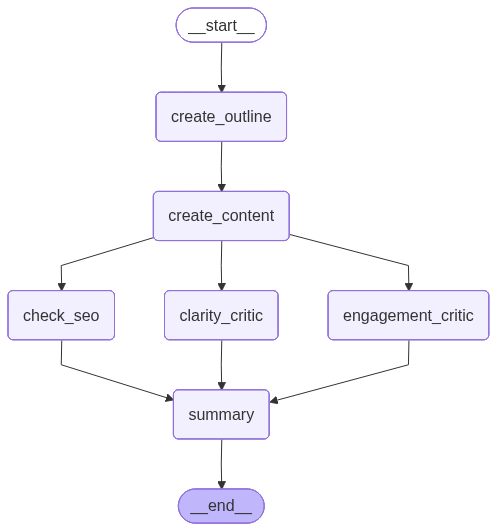

In [76]:
workflow

In [77]:
initial_state={'title':'AI in India'}
final_state=workflow.invoke(initial_state)
print(final_state)

{'title': 'AI in India', 'outline': '## Detailed Blog Outline: AI in India - Shaping the Future, One Algorithm at a Time\n\nThis outline provides a comprehensive structure for a blog post exploring the multifaceted landscape of Artificial Intelligence in India. It aims to be informative, engaging, and offer a balanced perspective on the opportunities, challenges, and future trajectory.\n\n---\n\n**Blog Title Options (Choose one or adapt):**\n\n*   AI in India: A Revolution in the Making\n*   India\'s AI Renaissance: Opportunities, Challenges, and the Road Ahead\n*   From Silicon Valley to the Ganges: India\'s Ascending Role in Artificial Intelligence\n*   Decoding India\'s AI Future: Innovation, Impact, and Inclusivity\n\n---\n\n**I. Introduction: The Dawn of AI in India (Hook & Context)**\n\n*   **A. Captivating Opening (Hook):**\n    *   Start with a compelling statistic, a futuristic scenario, or a thought-provoking question about AI\'s impact.\n    *   Example: "Imagine a doctor di

In [84]:
print(final_state['seo_report'].content)

Here's an analysis of the provided blog post on "AI in India for SEO," focusing on headers and keyword flow:

## Blog Analysis: AI in India: A Revolution in the Making

**Overall Impression:**

This blog post serves as a compelling and optimistic introduction to the topic of AI in India. It effectively highlights the potential and current landscape of AI adoption, framing it as a transformative force for the nation. The tone is positive and forward-looking, emphasizing both opportunities and challenges.

**Header Analysis:**

*   **Main Header:** "AI in India: A Revolution in the Making"
    *   **Strength:** This is an excellent, attention-grabbing header. It's concise, directly addresses the topic, and uses strong, evocative language ("Revolution in the Making") to create intrigue and suggest significant change.
    *   **SEO Potential:** Contains the primary keywords "AI in India" which is strong for searchability. The addition of "Revolution in the Making" adds a hook that could im

In [85]:
print(final_state['clarity_report'])

Here's a professional copyedit of your blog post on AI in India:

## AI in India: A Revolution in the Making

**Review:**

**1. Redundancy:**

*   "AI, the capability of machines to perform tasks typically requiring human intelligence, holds immense promise for a nation like India, poised to tackle developmental challenges and fuel economic growth."
*   "Driven by abundant data, a growing talent pool, and digital transformation, AI is set to revolutionize industries and improve lives."

These sentences convey similar ideas about AI's potential impact and the factors driving it. The first focuses on promise and tackling challenges, while the second highlights revolutionizing industries and improving lives. While not *exactly* the same, there's overlap in the optimistic framing and the idea of broad positive change.

**2. Jargon:**

*   **"Vernacular AI"**: While understandable in context, for a broader audience, it might be helpful to briefly explain what this means, or consider a sligh

In [87]:
print(final_state['engagement_report'])

Okay, I'm ready to put on my critical reader hat! Please paste the blog post you'd like me to analyze. Once you provide the content, I'll give you my ratings and feedback.
